# Per-electrode CNN-layer correspondence

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
_c = load_cache('01_stimulus_construction')
W = _c['W']
H = _c['H']

_c = load_cache('02_electrode_characterization')
electrode_type_df = _c['electrode_type_df']

_c = load_cache('05_cnn_representations')
cnn_layer_rdms_primary = _c['cnn_layer_rdms_primary']


In [4]:
alldat = ec.load_alldat()


In [5]:
# @title Rebuild per-electrode dat2 responses + per-electrode RDMs (crossnobis) + preferred CNN depth

LAYER_DEPTH = {L: i for i, L in enumerate(layer_names)}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
NOISE_RDM = upper_tri(np.abs(COND_NOISE[:, None] - COND_NOISE[None, :]).astype(float))

elec_cache = ec.build_elec_cache(alldat)
electrode_rdm = lambda s, ch: ec.electrode_rdm(elec_cache, s, ch)

def preferred_depth(R, cnn_rdms=None):
    """Best-matching CNN layer (raw and noise-partialled Spearman) for one electrode RDM."""
    cnn_rdms = cnn_rdms if cnn_rdms is not None else cnn_layer_rdms_primary
    ue = upper_tri(R); raw, par = {}, {}
    for L in layer_names:
        uc = upper_tri(cnn_rdms[L])
        m = np.isfinite(ue) & np.isfinite(uc)
        raw[L] = stats.spearmanr(ue[m], uc[m])[0] if m.sum() >= 15 else np.nan
        par[L] = partial_spearman(ue, uc, NOISE_RDM)
    def best(d):
        v = {k: x for k, x in d.items() if np.isfinite(x)}
        if not v:
            return np.nan, np.nan
        bl = max(v, key=v.get)
        arr = np.array([d[L] for L in layer_names], float)
        return LAYER_DEPTH[bl], float(np.nanmax(arr) - np.nanmin(arr))
    d_r, sh_r = best(raw); d_p, sh_p = best(par)
    return dict(d_raw=d_r, shape_raw=sh_r, d_partial=d_p, shape_partial=sh_p,
                **{f'raw_{L}': raw[L] for L in layer_names}, **{f'par_{L}': par[L] for L in layer_names})

print('Per-electrode dat2 responses rebuilt for subjects:', list(elec_cache.keys()))


Per-electrode dat2 responses rebuilt for subjects: [0, 3, 4, 5, 6]


101 electrodes characterised (region-based selection: early_visual + ventral_temporal)
region
early_visual        24
ventral_temporal    77
dtype: int64


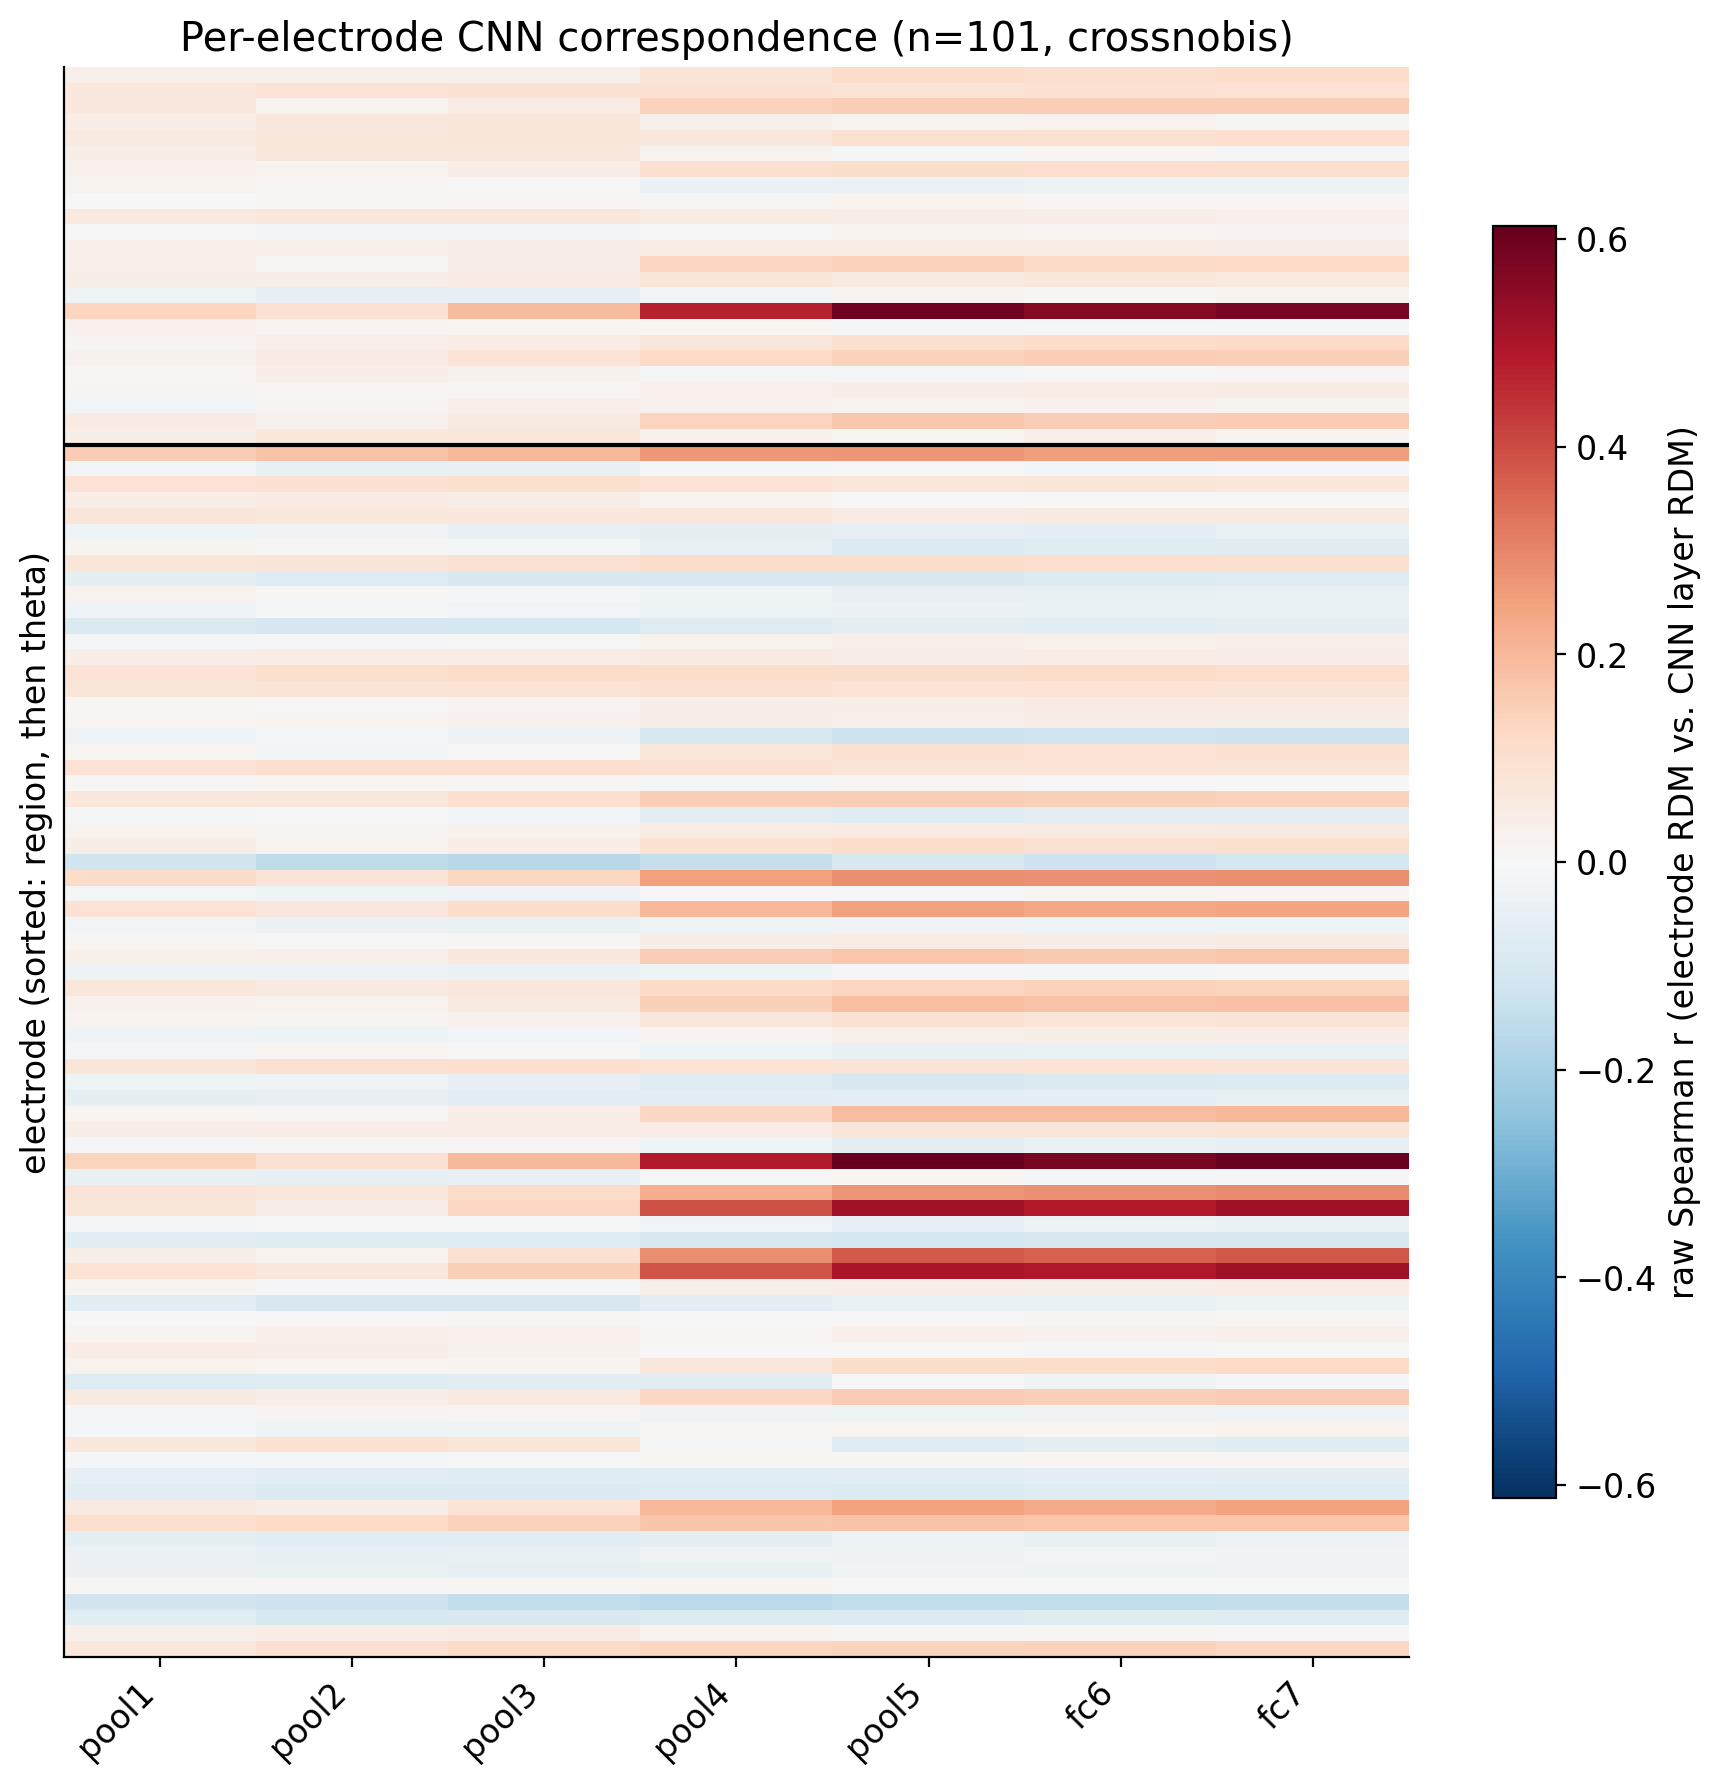

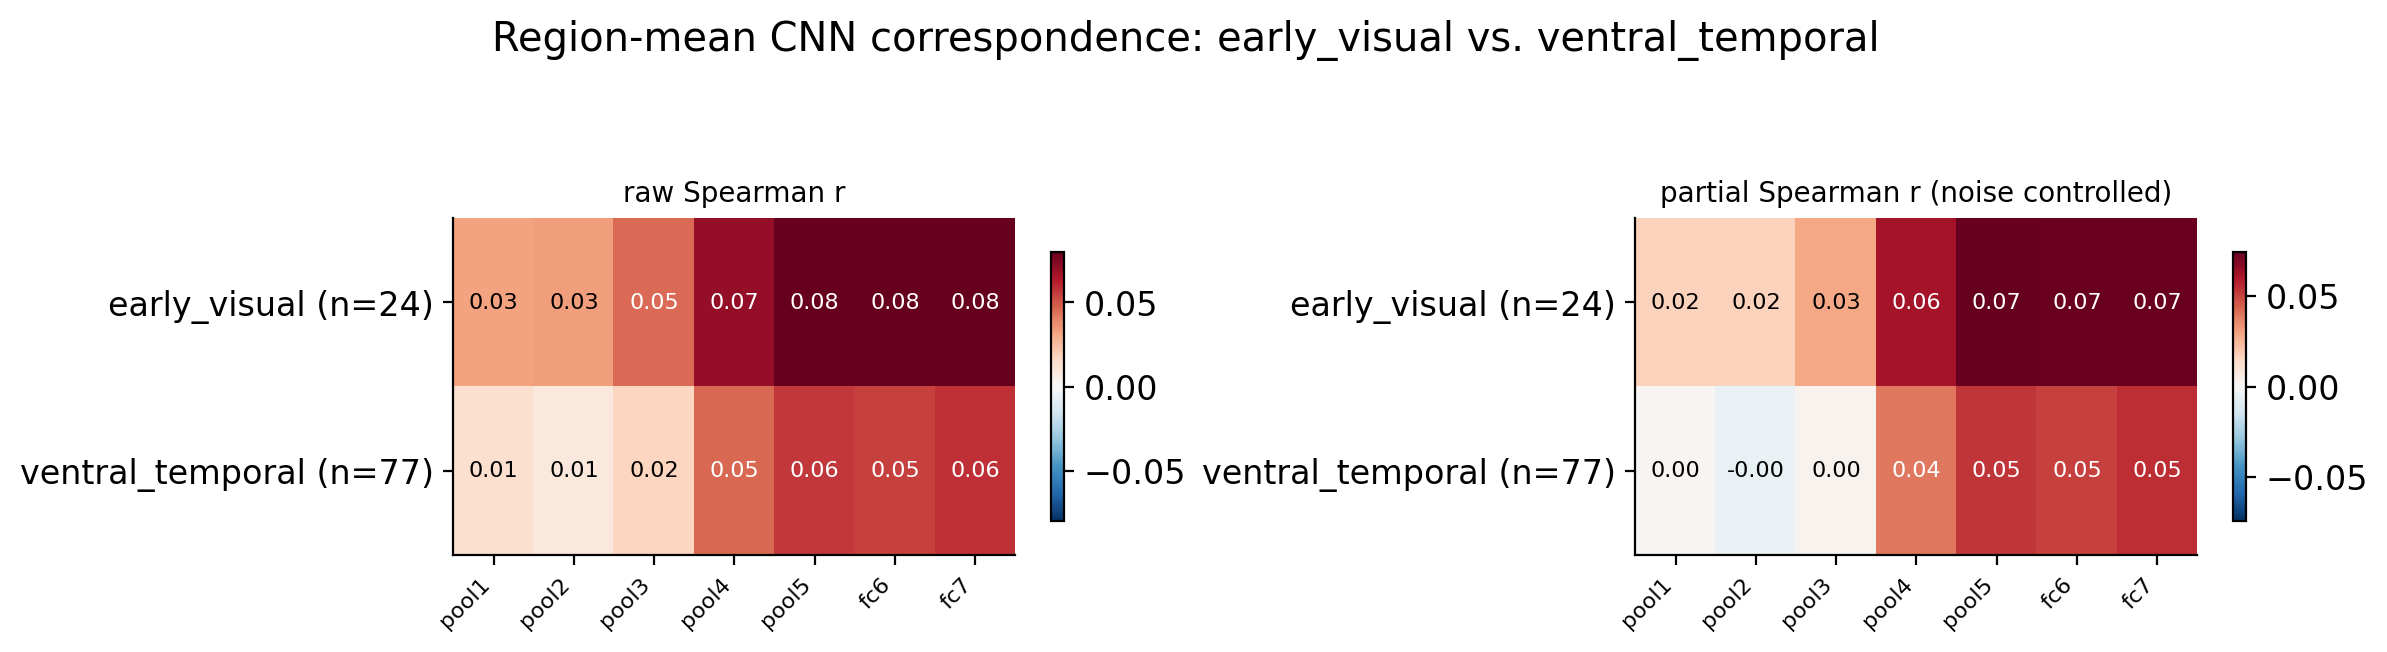

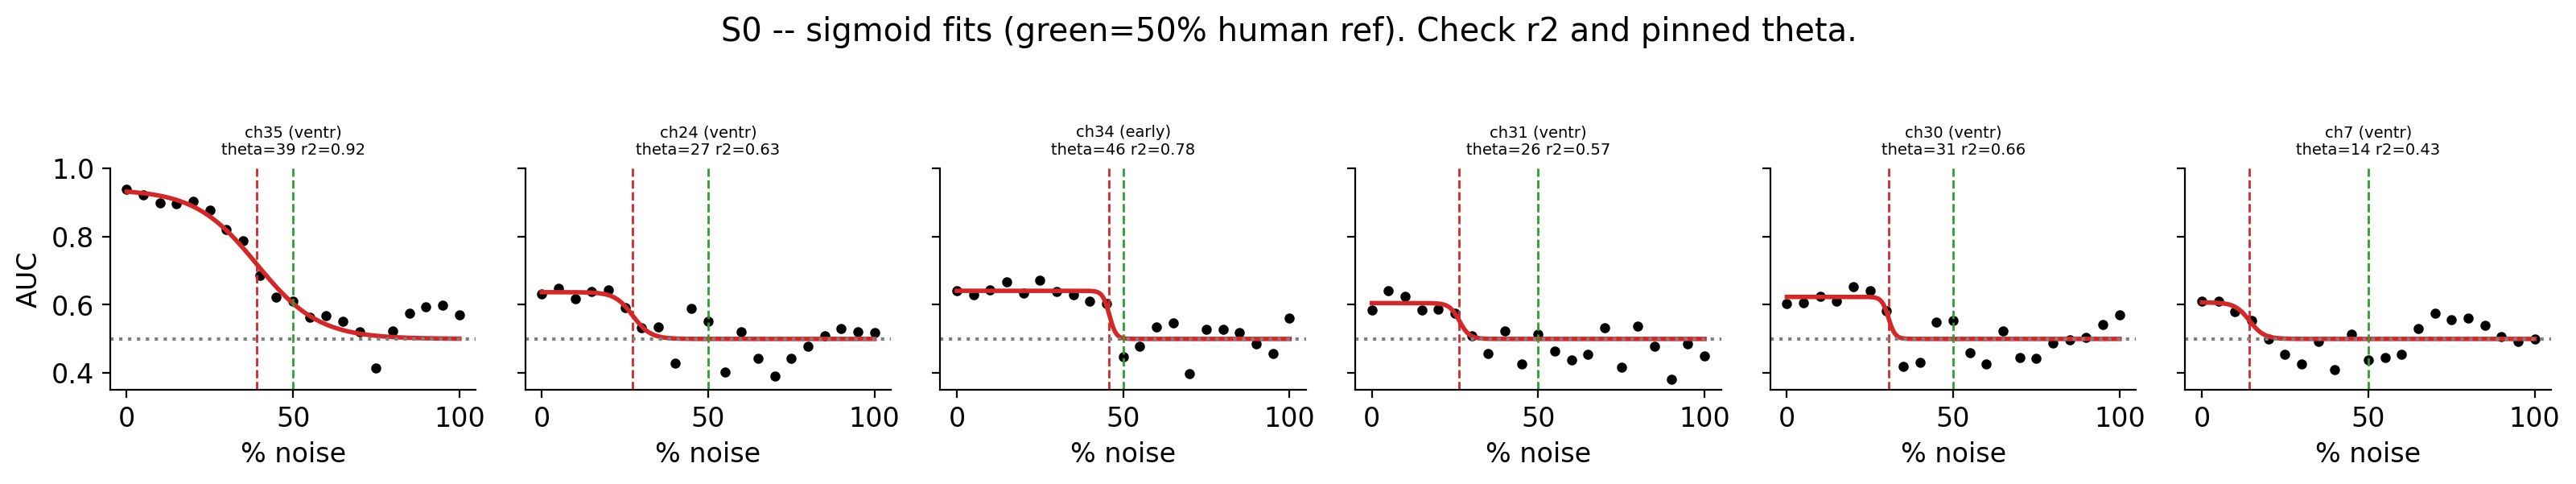

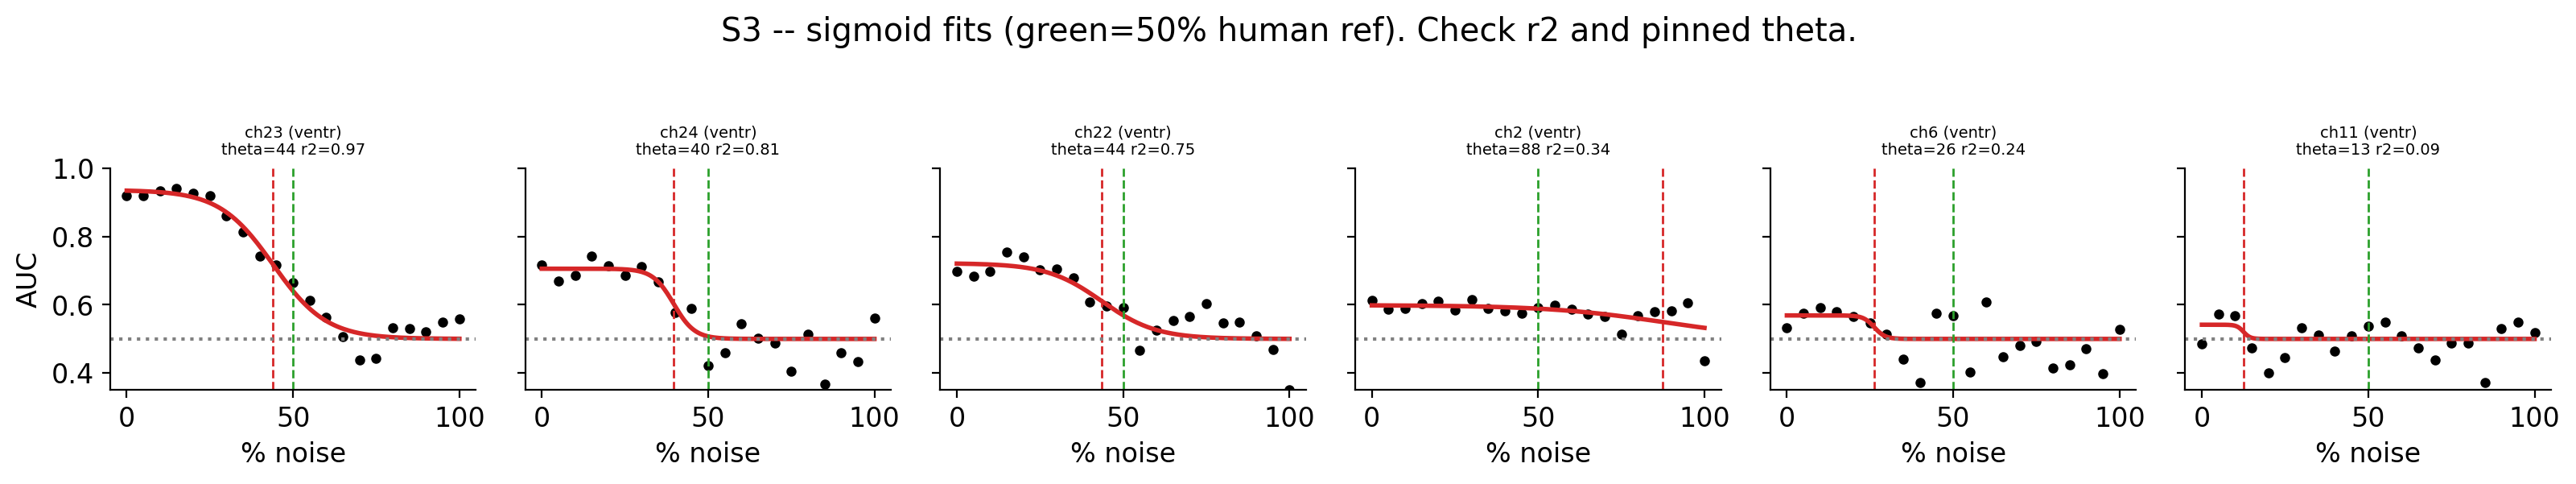

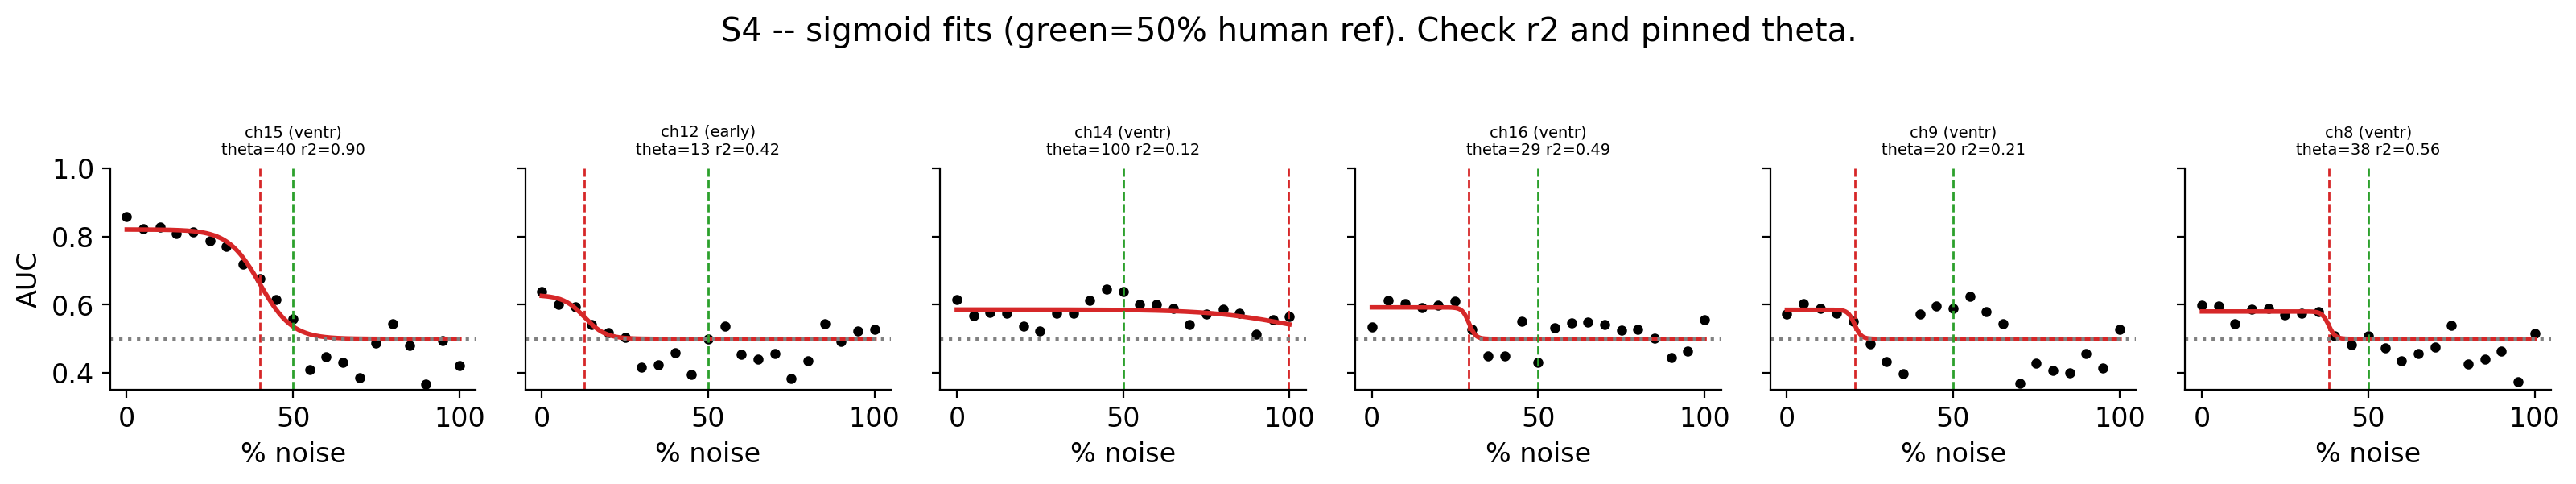

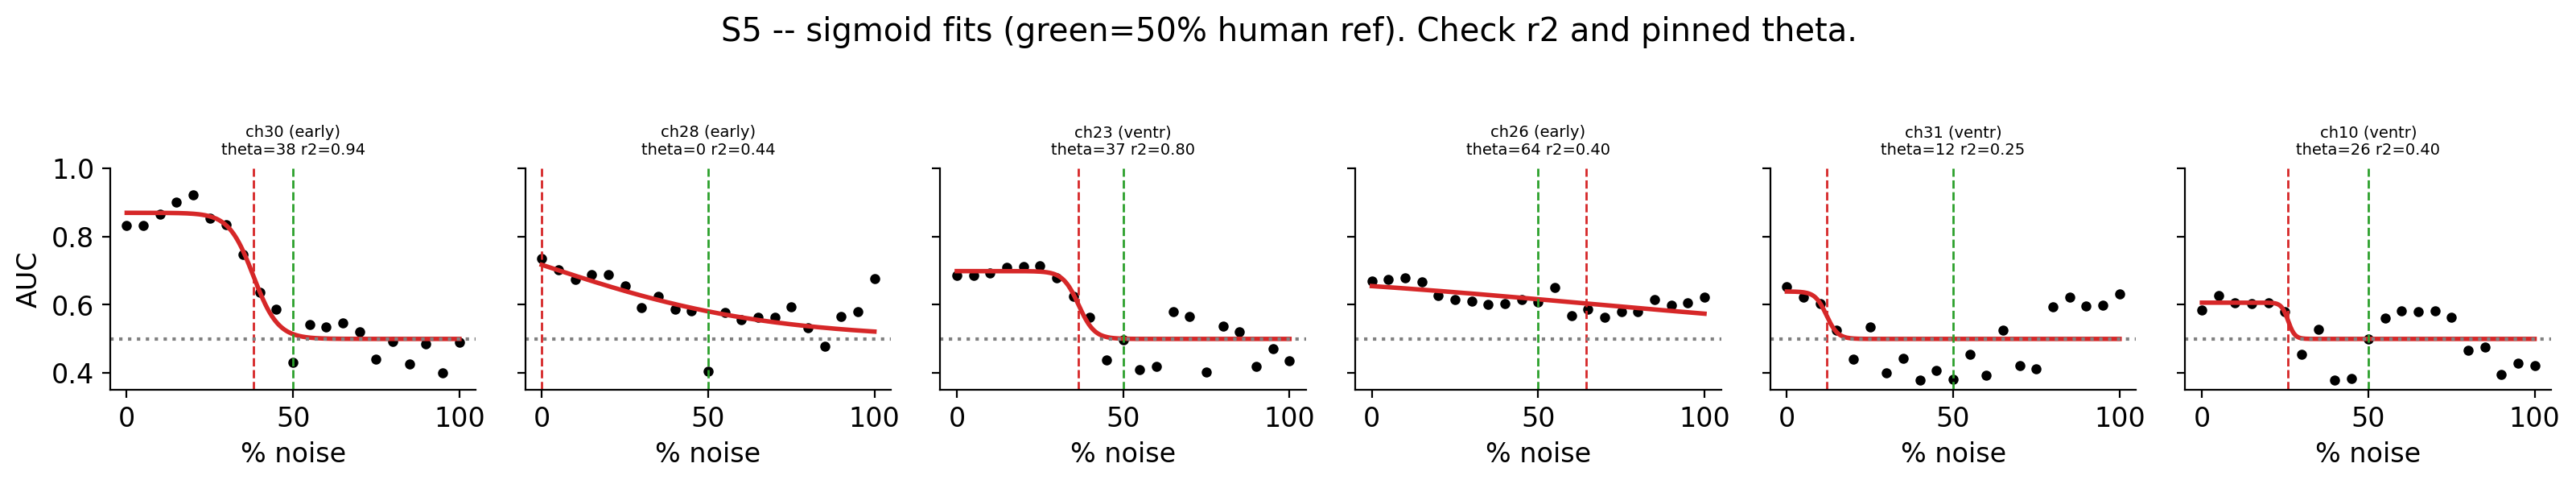

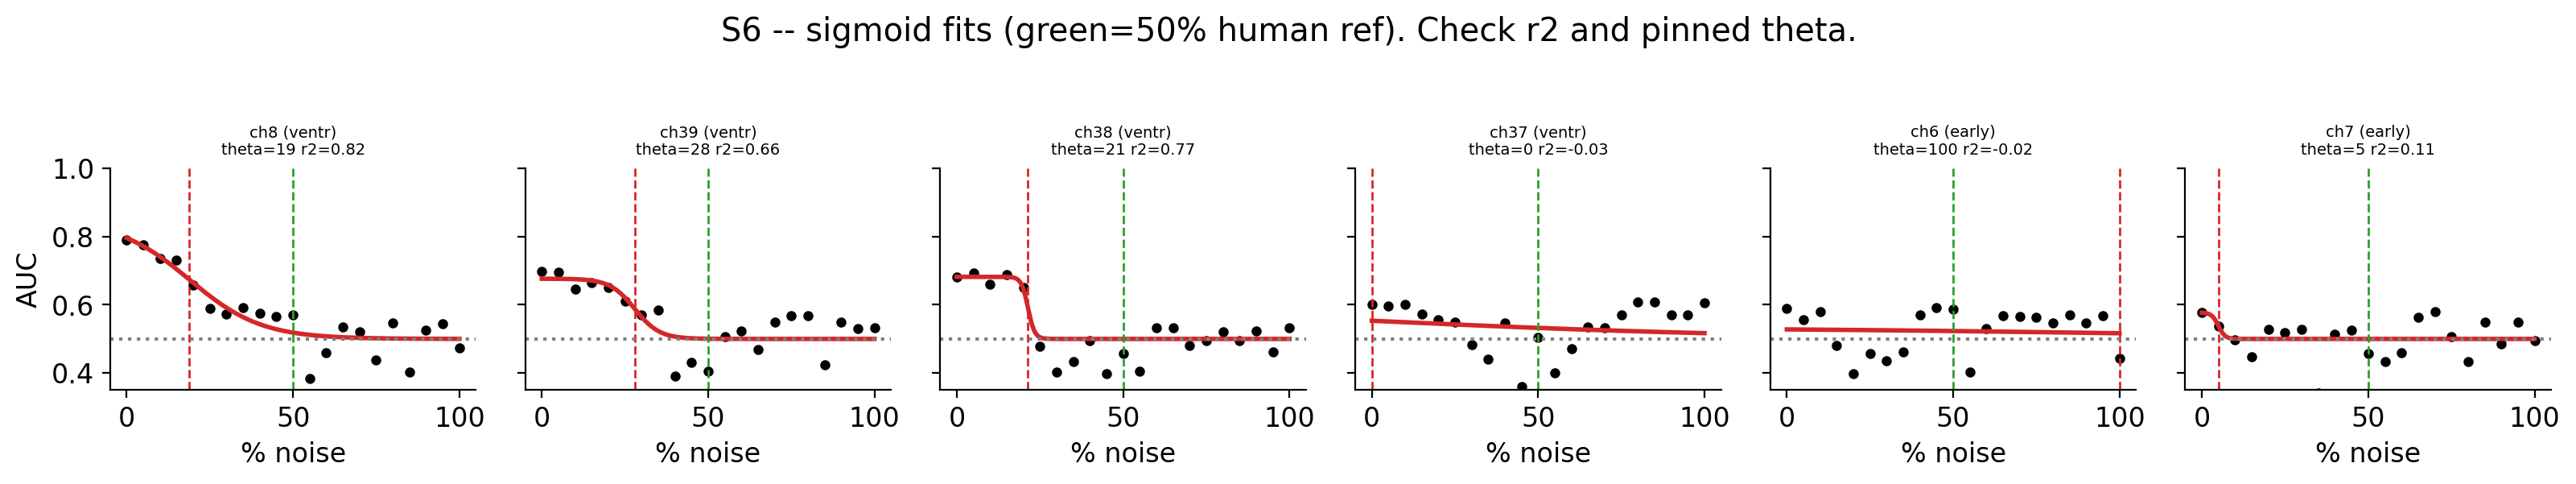

In [6]:
# @title Sigmoid AUC-vs-noise fits (theta, slope) per electrode + per-electrode CNN correspondence heatmaps

NOISE_HALFWIN = 10

def auc_vs_noise(s, ch):
    c = elec_cache[s]; loc = np.where(c['good'] == ch)[0][0]
    x, y = c['resp'][:, loc], (c['cat'] == 2).astype(int)
    out = np.full(len(NOISE_LEVELS), np.nan)
    for k, n in enumerate(NOISE_LEVELS):
        m = np.abs(c['noise'] - n) <= NOISE_HALFWIN
        if m.sum() >= 12:
            out[k] = cv_auc(x[m], y[m])
    return out

auc_curves, rows = {}, []
for s in usable:
    sub = electrode_type_df[(electrode_type_df['subject'] == s) &
                             (electrode_type_df['has_valid_loc']) &
                             (electrode_type_df['region'].isin(['early_visual', 'ventral_temporal']))]
    for ch in sub['channel'].astype(int).values:
        R = electrode_rdm(s, ch)
        if R is None:
            continue
        curve = auc_vs_noise(s, ch); auc_curves[(s, ch)] = curve
        th, sl, r2 = fit_threshold(curve)
        rec = dict(subject=s, channel=ch, theta=th, slope=sl, fit_r2=r2,
                   auc_clean=float(np.nanmax(curve[:3])) if np.isfinite(curve[:3]).any() else np.nan)
        rec.update(preferred_depth(R))
        rec['region'] = sub.loc[sub['channel'] == ch, 'region'].iloc[0]
        rows.append(rec)
elec = pd.DataFrame(rows)
print(f'{len(elec)} electrodes characterised (region-based selection: early_visual + ventral_temporal)')
print(elec.groupby('region').size())

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
raw_cols = [f'raw_{L}' for L in layer_names]; par_cols = [f'par_{L}' for L in layer_names]

elec_sorted = elec.sort_values(['region', 'theta']).reset_index(drop=True)
n_e = len(elec_sorted)
fig, ax = plt.subplots(figsize=(9, max(4, 0.09 * n_e)))
vmax = np.nanmax(np.abs(elec_sorted[raw_cols].values))
im = ax.imshow(elec_sorted[raw_cols].values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, ha='right')
ax.set_ylabel('electrode (sorted: region, then theta)'); ax.set_yticks([])
boundary = (elec_sorted['region'] == 'early_visual').sum()
ax.axhline(boundary - 0.5, color='black', lw=1.5)
fig.colorbar(im, ax=ax, label='raw Spearman r (electrode RDM vs. CNN layer RDM)', shrink=0.8)
ax.set_title(f'Per-electrode CNN correspondence (n={n_e}, crossnobis)')
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig01'))); plt.close(fig)

region_raw = elec.groupby('region')[raw_cols].mean().reindex(['early_visual', 'ventral_temporal'])
region_par = elec.groupby('region')[par_cols].mean().reindex(['early_visual', 'ventral_temporal'])
region_n = elec.groupby('region').size().reindex(['early_visual', 'ventral_temporal'])
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, grid, title in zip(axes, [region_raw, region_par], ['raw Spearman r', 'partial Spearman r (noise controlled)']):
    vmax2 = np.nanmax(np.abs(grid.values))
    im = ax.imshow(grid.values, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2, aspect='auto')
    ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(grid))); ax.set_yticklabels([f'{r} (n={n})' for r, n in zip(grid.index, region_n)])
    ax.set_title(title, fontsize=10)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if abs(val) > vmax2*0.5 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Region-mean CNN correspondence: early_visual vs. ventral_temporal', y=1.08)
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig02'))); plt.close(fig)

for s in usable:
    e = elec[elec['subject'] == s].nlargest(6, 'auc_clean')
    if len(e) == 0:
        continue
    fig, axes = plt.subplots(1, len(e), figsize=(2.7*len(e), 2.9), sharey=True)
    for ax, (_, r) in zip(np.atleast_1d(axes), e.iterrows()):
        cv = auc_curves.get((s, int(r['channel'])))
        if cv is None:
            ax.axis('off'); continue
        ax.plot(NOISE_LEVELS, cv, 'ko', ms=3.5)
        if np.isfinite(r['theta']):
            m = np.isfinite(cv)
            try:
                popt, _ = curve_fit(auc_sigmoid, NOISE_LEVELS[m], cv[m],
                                     p0=[max(float(np.nanmax(cv)), .55), 50., 10.],
                                     bounds=([.5,0,1],[1.,100,60]), maxfev=30000)
                xs = np.linspace(0, 100, 200)
                ax.plot(xs, auc_sigmoid(xs, *popt), '-', color='tab:red', lw=2)
                ax.axvline(r['theta'], color='tab:red', ls='--', lw=1)
            except Exception:
                pass
        ax.axhline(.5, color='gray', ls=':'); ax.axvline(50, color='tab:green', ls='--', lw=1)
        ax.set_ylim(.35, 1.0); ax.set_xlabel('% noise')
        ax.set_title(f"ch{int(r['channel'])} ({r['region'][:5]})\ntheta={r['theta']:.0f} r2={r['fit_r2']:.2f}", fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel('AUC')
    plt.suptitle(f'S{s} -- sigmoid fits (green=50% human ref). Check r2 and pinned theta.', y=1.04)
    plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig03'))); plt.close(fig)


DEPTH PREFERENCE BY REGION (crossnobis RSA)
--- S0 (n=23) ---
  raw    : [0.005 0.001 0.008 0.03  0.039 0.039 0.043]
  partial: [-0.005 -0.011 -0.005  0.023  0.036  0.035  0.04 ]
  early<ventral? p=0.6601 (median depth: early=4.0, ventral=4.0)
--- S3 (n=19) ---
  raw    : [0.051 0.047 0.065 0.107 0.122 0.12  0.123]
  partial: [0.034 0.027 0.046 0.105 0.123 0.119 0.121]
  untestable (early n=0, ventral n=19)
--- S4 (n=15) ---
  raw    : [ 0.001 -0.006  0.001  0.028  0.037  0.037  0.039]
  partial: [-0.012 -0.021 -0.016  0.014  0.027  0.028  0.03 ]
  untestable (early n=2, ventral n=13)
--- S5 (n=27) ---
  raw    : [0.017 0.014 0.023 0.05  0.061 0.061 0.064]
  partial: [0.01  0.005 0.014 0.052 0.067 0.065 0.068]
  early<ventral? p=0.1685 (median depth: early=4.0, ventral=5.0)
--- S6 (n=17) ---
  raw    : [0.012 0.015 0.023 0.041 0.047 0.044 0.045]
  partial: [-0.004 -0.003  0.002  0.021  0.031  0.026  0.028]
  untestable (early n=2, ventral n=15)

--- AGGREGATED across subjects ---
  raw

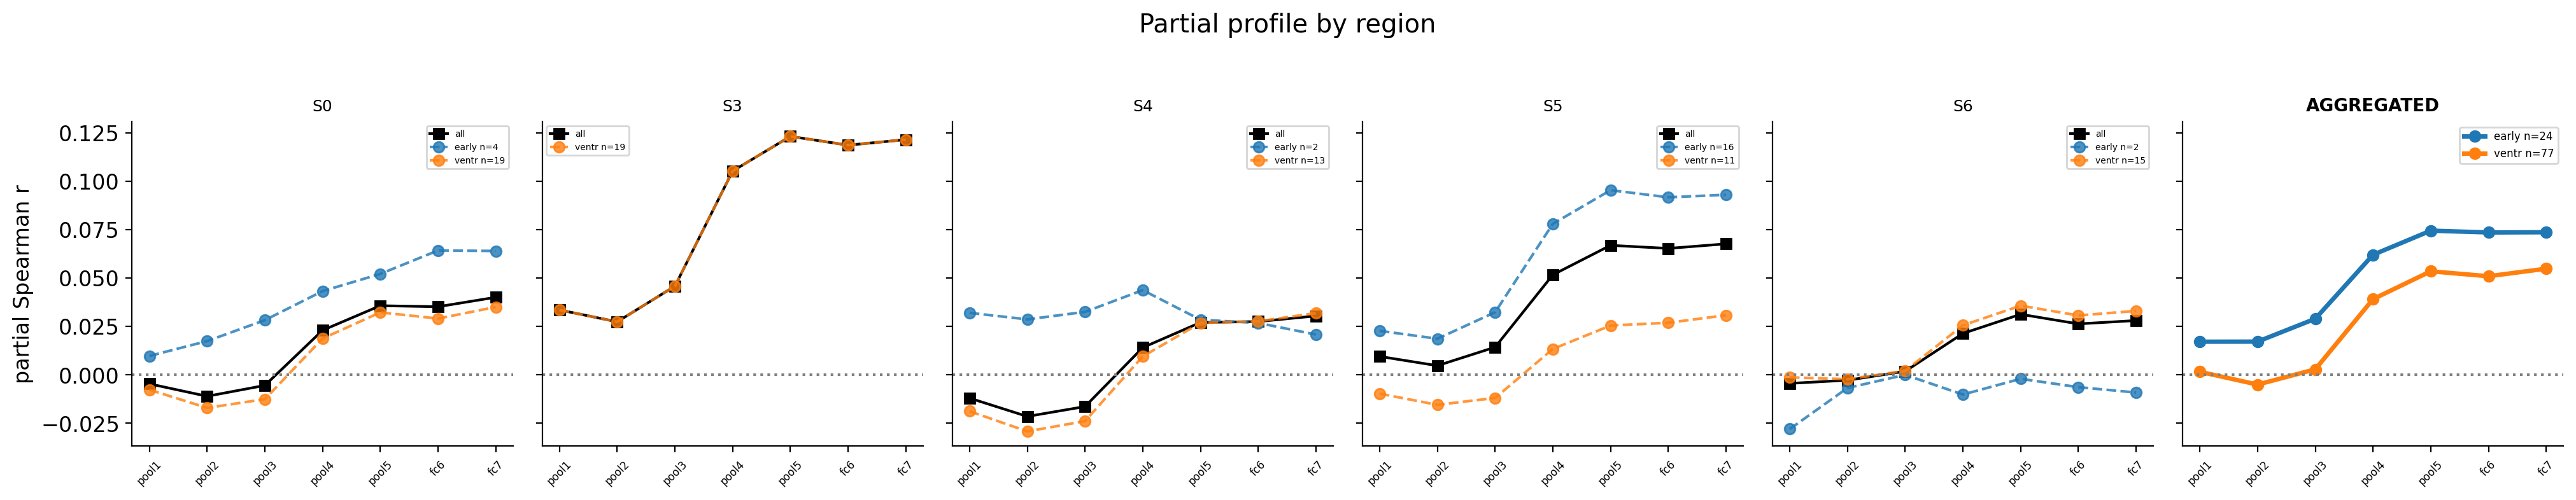

In [7]:
# @title Depth preference by region: early_visual vs. ventral_temporal

print('DEPTH PREFERENCE BY REGION (crossnobis RSA)')

for s in usable:
    e = elec[elec['subject'] == s]
    if len(e) == 0:
        print(f'S{s}: empty'); continue
    print(f'--- S{s} (n={len(e)}) ---')
    print('  raw    :', np.round(e[raw_cols].mean().values, 3))
    print('  partial:', np.round(e[par_cols].mean().values, 3))
    ev = e.loc[e['region']=='early_visual', 'd_partial'].dropna()
    vt = e.loc[e['region']=='ventral_temporal', 'd_partial'].dropna()
    if len(ev) >= 3 and len(vt) >= 3:
        p = stats.mannwhitneyu(ev, vt, alternative='less')[1]
        print(f'  early<ventral? p={p:.4f} '
              f'(median depth: early={ev.median():.1f}, ventral={vt.median():.1f})')
    else:
        print(f'  untestable (early n={len(ev)}, ventral n={len(vt)})')

print('\n--- AGGREGATED across subjects ---')
print('  raw    :', np.round(elec[raw_cols].mean().values, 3))
print('  partial:', np.round(elec[par_cols].mean().values, 3))
ev = elec.loc[elec['region']=='early_visual', 'd_partial'].dropna()
vt = elec.loc[elec['region']=='ventral_temporal', 'd_partial'].dropna()
if len(ev) >= 3 and len(vt) >= 3:
    p = stats.mannwhitneyu(ev, vt, alternative='less')[1]
    print(f'  early<ventral? p={p:.4f} (median depth: early={ev.median():.1f}, ventral={vt.median():.1f})')

fig, axes = plt.subplots(1, len(usable)+1, figsize=(3.4*(len(usable)+1), 3.8), sharey=True)
for ax, s in zip(axes[:-1], usable):
    e = elec[elec['subject'] == s]
    if len(e) == 0:
        ax.axis('off'); continue
    ax.plot(range(len(layer_names)), e[par_cols].mean().values, 's-', color='k', label='all')
    for reg, c in REG_COLORS.items():
        g = e[e['region'] == reg]
        if len(g) >= 2:
            ax.plot(range(len(layer_names)), g[par_cols].mean().values, 'o--', color=c, alpha=.8, label=f'{reg[:5]} n={len(g)}')
    ax.axhline(0, color='gray', ls=':'); ax.set_title(f'S{s}', fontsize=9)
    ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, fontsize=6)
    ax.legend(fontsize=5)
ax = axes[-1]
for reg, c in REG_COLORS.items():
    g = elec[elec['region'] == reg]
    if len(g) >= 2:
        ax.plot(range(len(layer_names)), g[par_cols].mean().values, 'o-', color=c, lw=2.5, label=f'{reg[:5]} n={len(g)}')
ax.axhline(0, color='gray', ls=':'); ax.set_title('AGGREGATED', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, fontsize=6); ax.legend(fontsize=6)
axes[0].set_ylabel('partial Spearman r')
plt.suptitle('Partial profile by region', y=1.03)
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig04'))); plt.close(fig)


Depth vs. threshold (position) and slope (shape)
electrodes with reliable fit: 21/101
S0 (n= 6): threshold rho=+0.586 p=0.221 | slope rho=+0.802 p=0.055
S3: n=4 insufficient
S4: n=3 insufficient
S5: n=5 insufficient
S6: n=3 insufficient

AGGREGATED: threshold rho=+0.353 p=0.1171 | slope rho=+0.459 p=0.0365, theta median=30.5%


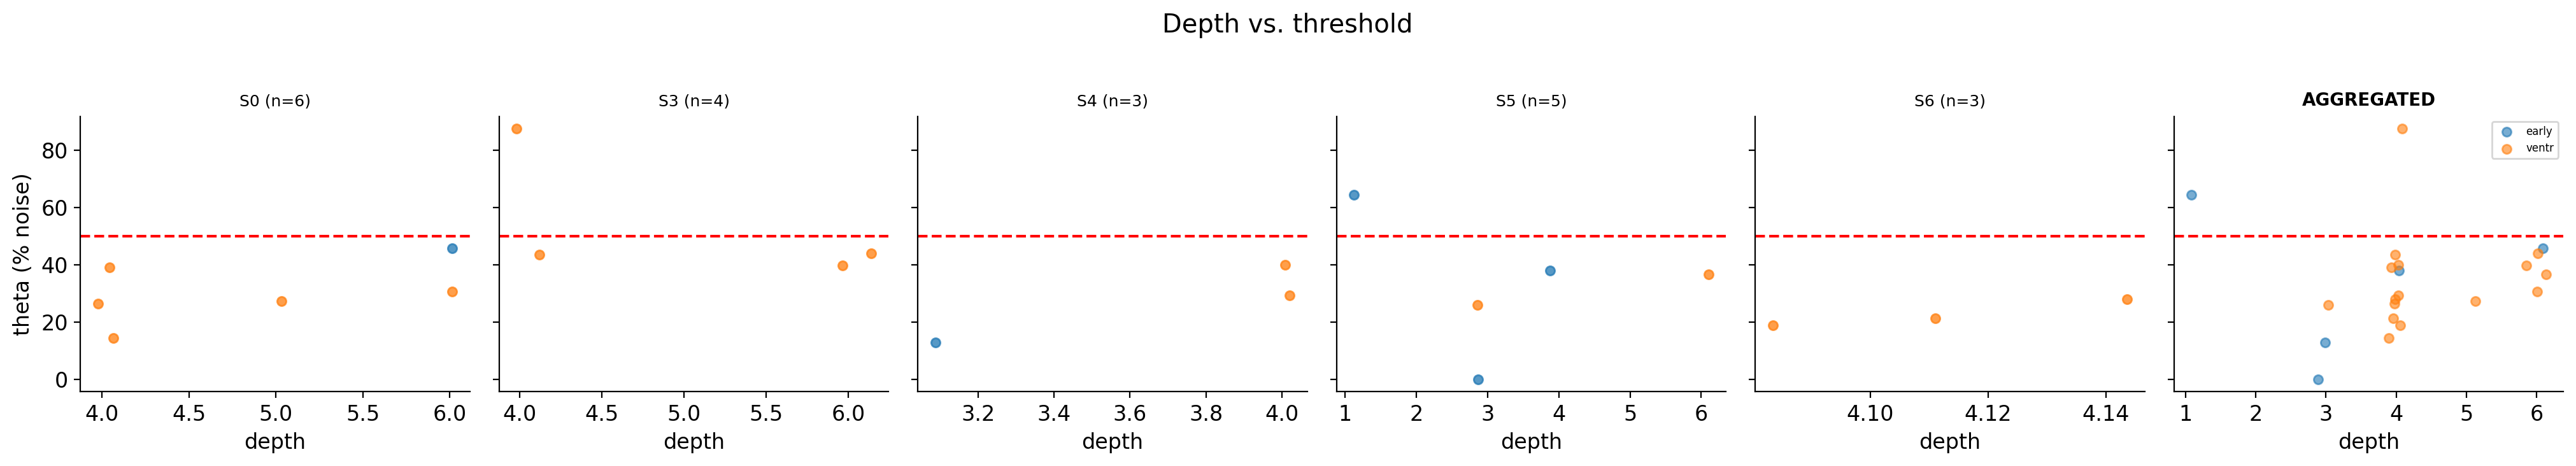

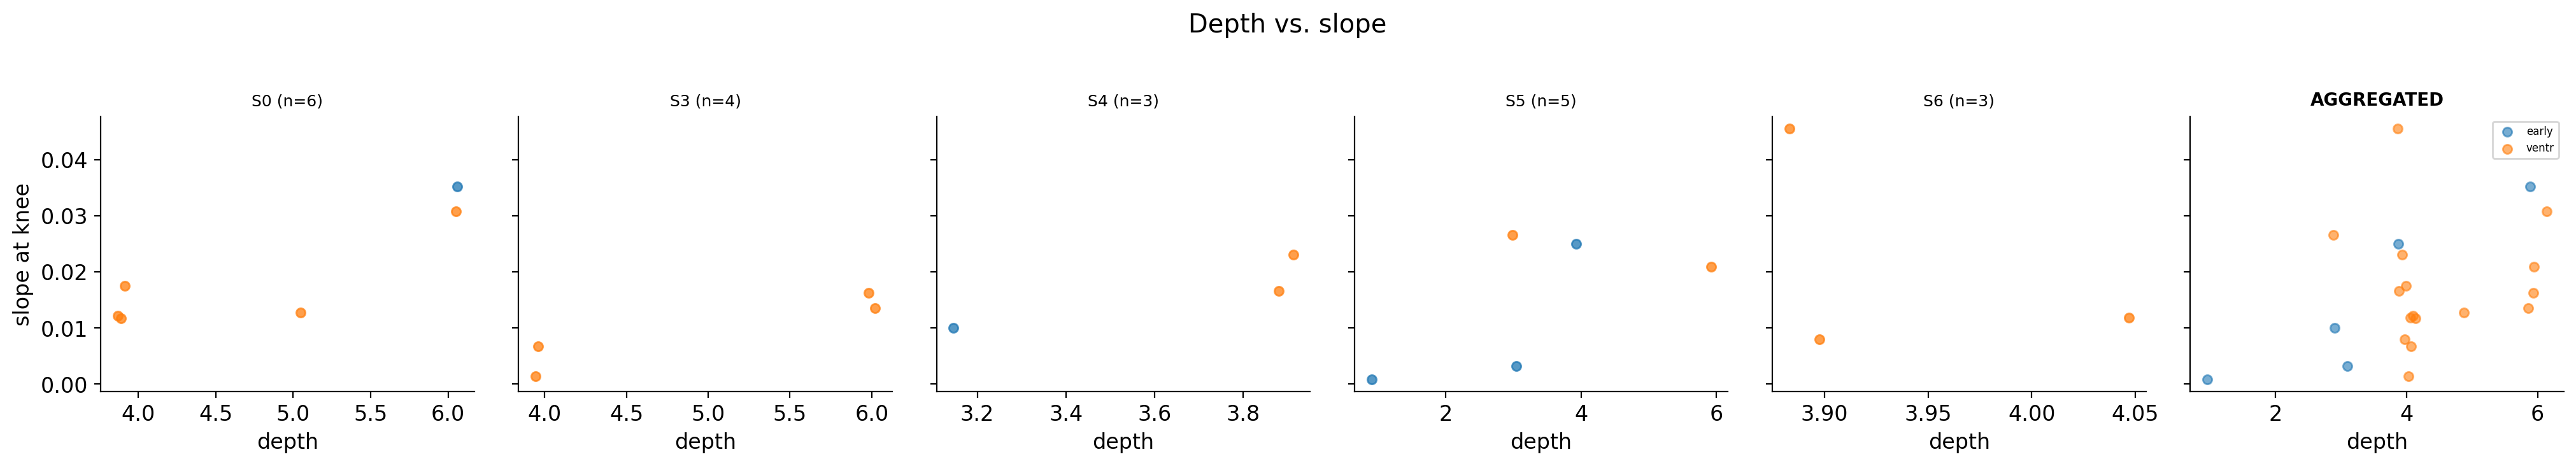

In [8]:
# @title CNN layer depth vs. noise-collapse threshold and steepness

print('Depth vs. threshold (position) and slope (shape)')
ok = elec.dropna(subset=['d_partial', 'theta', 'slope'])
ok = ok[(ok['fit_r2'] > .3) & (ok['auc_clean'] > .6)]
print(f'electrodes with reliable fit: {len(ok)}/{len(elec)}')

h1 = []
for s in usable:
    o = ok[ok['subject'] == s]
    if len(o) < 6:
        print(f'S{s}: n={len(o)} insufficient'); continue
    ra, pa = stats.spearmanr(o['d_partial'], o['theta'])
    rb, pb = stats.spearmanr(o['d_partial'], o['slope'])
    h1.append(dict(subject=s, rho_theta=ra, rho_slope=rb))
    print(f'S{s} (n={len(o):>2}): threshold rho={ra:+.3f} p={pa:.3f} | slope rho={rb:+.3f} p={pb:.3f}')
h1_df = pd.DataFrame(h1)
if len(h1_df) >= 3:
    print(f'\nthreshold, per-subject sign check: {(h1_df["rho_theta"]>0).sum()}/{len(h1_df)} rho>0')
    print(f'slope, per-subject sign check: {(h1_df["rho_slope"]>0).sum()}/{len(h1_df)} rho>0 (predicted >0)')

if len(ok) >= 8:
    ra, pa = stats.spearmanr(ok['d_partial'], ok['theta'])
    rb, pb = stats.spearmanr(ok['d_partial'], ok['slope'])
    print(f'\nAGGREGATED: threshold rho={ra:+.3f} p={pa:.4f} | slope rho={rb:+.3f} p={pb:.4f}, theta median={ok["theta"].median():.1f}%')

for col, lab in [('theta', 'theta (% noise)'), ('slope', 'slope at knee')]:
    fig, axes = plt.subplots(1, len(usable)+1, figsize=(3.4*(len(usable)+1), 3.6), sharey=True)
    for ax, s in zip(axes[:-1], usable):
        o = ok[ok['subject'] == s]
        for reg, c in REG_COLORS.items():
            g = o[o['region'] == reg]
            ax.scatter(g['d_partial']+np.random.uniform(-.15,.15,len(g)), g[col], color=c, alpha=.75, s=26)
        ax.set_title(f'S{s} (n={len(o)})', fontsize=9); ax.set_xlabel('depth')
        if col == 'theta':
            ax.axhline(50, color='r', ls='--')
    ax = axes[-1]
    for reg, c in REG_COLORS.items():
        g = ok[ok['region'] == reg]
        ax.scatter(g['d_partial']+np.random.uniform(-.15,.15,len(g)), g[col], color=c, alpha=.6, s=26, label=reg[:5])
    if col == 'theta':
        ax.axhline(50, color='r', ls='--')
    ax.set_title('AGGREGATED', fontsize=10, fontweight='bold'); ax.set_xlabel('depth'); ax.legend(fontsize=6)
    axes[0].set_ylabel(lab)
    plt.suptitle(f'{"Depth vs. threshold" if col=="theta" else "Depth vs. slope"}', y=1.02)
    plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig05'))); plt.close(fig)


### Cross-check against the dat1 face-selectivity marker

The `d_partial`/theta/slope values above come entirely from the noisy
`dat2` task. As a independent cross-check, this section flags which of
those same electrodes are *also* face-selective on the clean `dat1`
localizer (AUC > 0.60) -- a criterion computed from a completely different
session, so marking electrodes this way cannot be circular with the theta
being tested.


Electrodes: 21 with a reliable sigmoid fit; 12 are ALSO face-selective on the independent dat1 localizer (AUC>0.6)


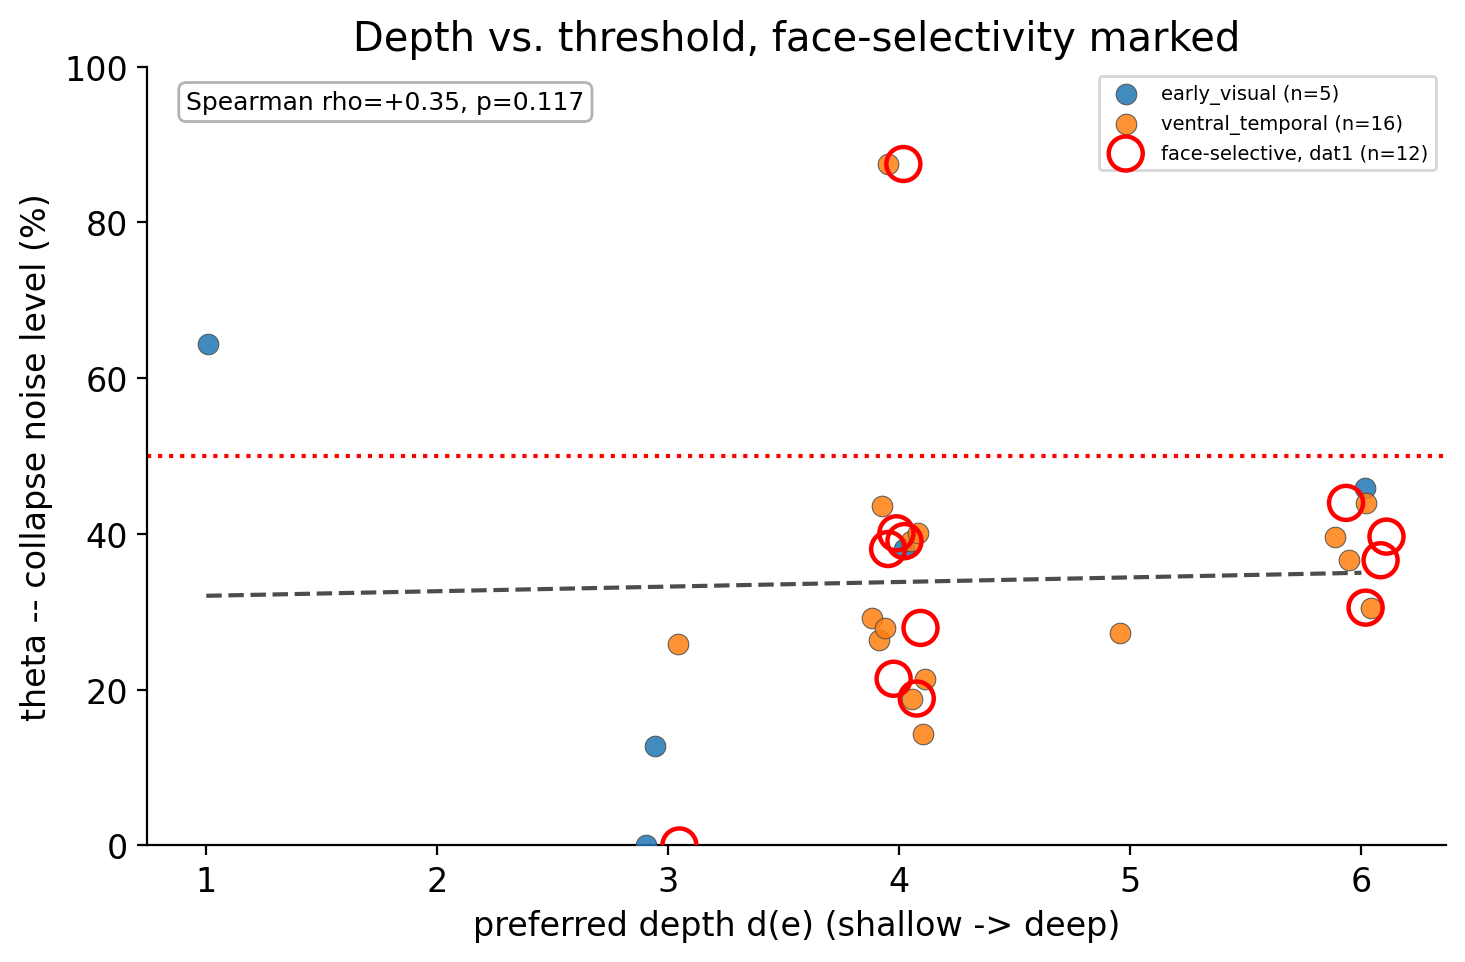

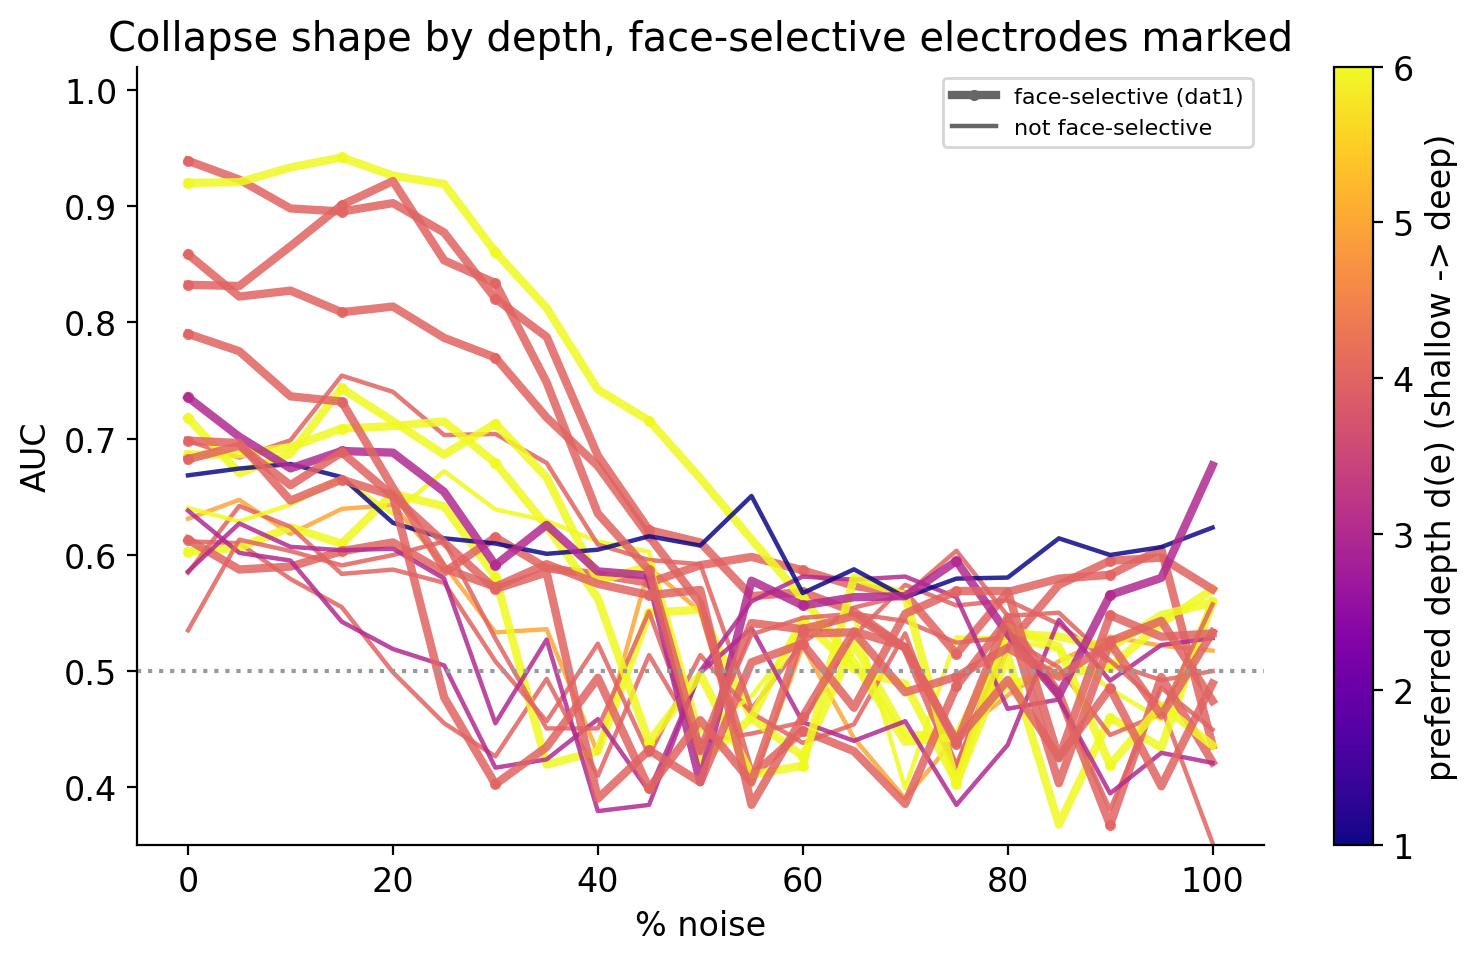

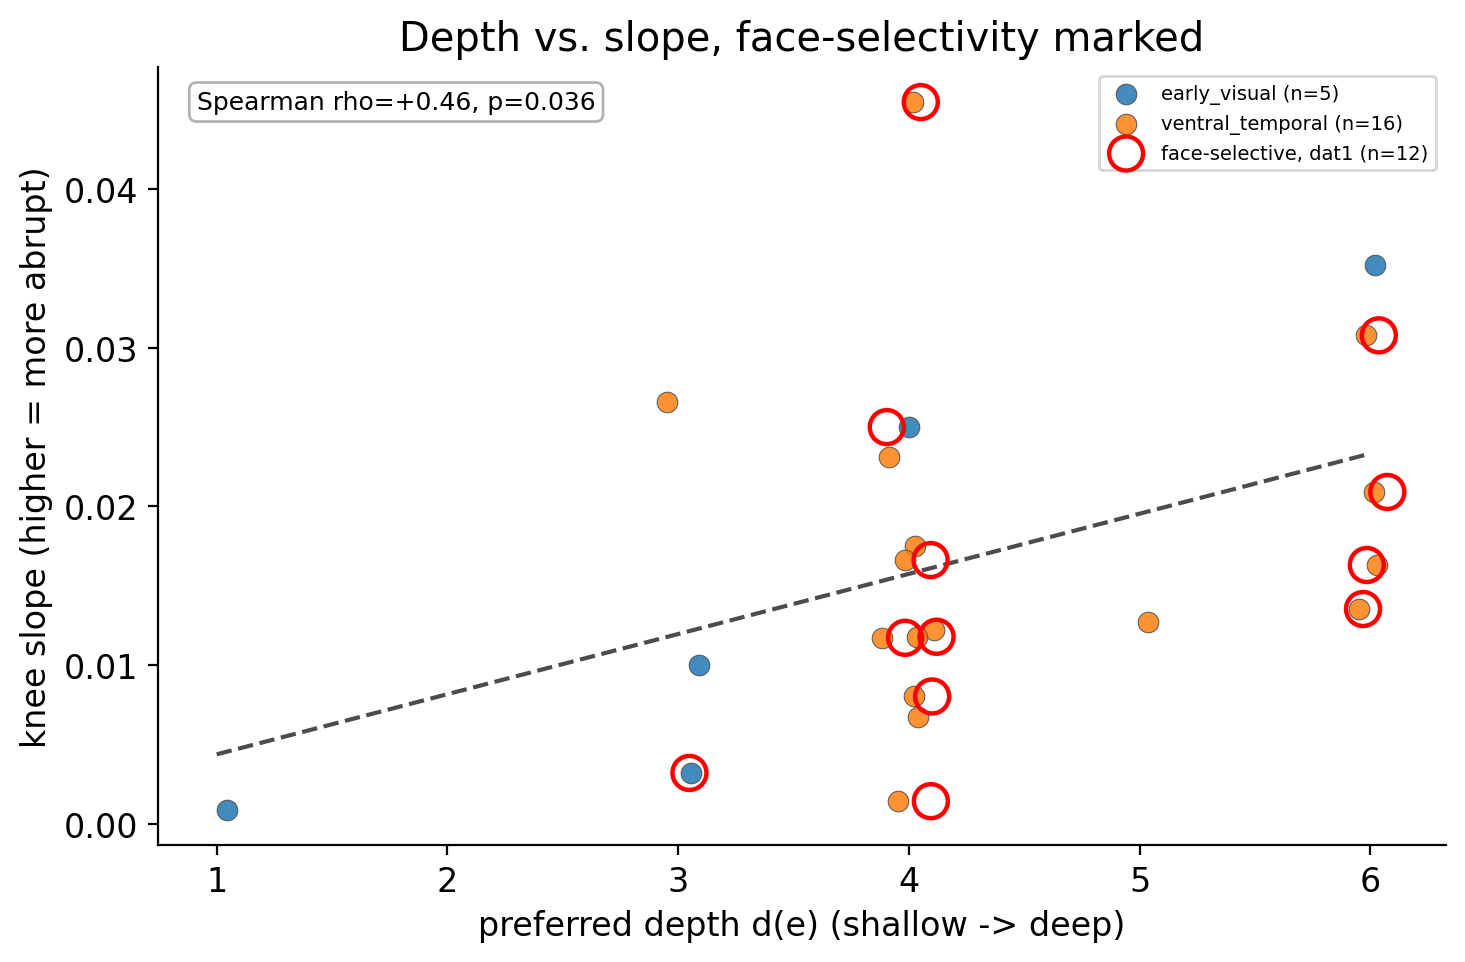

Red ring = electrode is face-selective on the dat1 localizer -- an independent check, not the
dat2 curve theta/slope were fit to. face_sel_dat1 is reused below in the collapse-threshold and population sections.


In [9]:
# @title Depth vs. threshold/slope re-plotted with dat1-localizer face-selectivity marked

FACE_SEL_CRIT = 0.60
trange_d1_h1 = np.arange(-200, 400)
response_d1_h1 = (trange_d1_h1 >= 100) & (trange_d1_h1 <= 350)

face_sel_dat1 = {}   # (subject, channel) -> bool, from the CLEAN dat1 localizer only
for s in usable:
    d1 = alldat[s][0]
    V_car, good = common_average_reference(d1['V'].astype('float64'))
    BB = broadband_power(V_car, fs=1000)
    ts = d1['t_on'][:, np.newaxis] + trange_d1_h1
    valid = (ts.min(1) >= 0) & (ts.max(1) < BB.shape[0])
    ep = BB[ts[valid], :]
    is_face = (np.asarray(d1['stim_id']).ravel()[valid] > 50).astype(int)
    resp = ep[:, response_d1_h1, :].mean(1)
    for ch_local, ch in enumerate(good):
        auc = cv_auc(resp[:, ch_local], is_face)
        face_sel_dat1[(s, int(ch))] = bool(np.isfinite(auc) and auc > FACE_SEL_CRIT)

ok = ok.copy()
ok['is_fs'] = ok.apply(lambda r: face_sel_dat1.get((int(r['subject']), int(r['channel'])), False), axis=1)
print(f"Electrodes: {len(ok)} with a reliable sigmoid fit; "
      f"{ok['is_fs'].sum()} are ALSO face-selective on the independent dat1 localizer (AUC>{FACE_SEL_CRIT})")

def scatter_h1_marked(ax, ycol, ylabel, title, ref50=False):
    for reg, c in REG_COLORS.items():
        g = ok[ok['region'] == reg]
        jitter = np.random.uniform(-.12, .12, len(g))
        ax.scatter(g['d_partial']+jitter, g[ycol], color=c, s=55, alpha=.85, edgecolors='0.3',
                   linewidths=.4, label=f'{reg} (n={len(g)})', zorder=3)
    fs_ = ok[ok['is_fs']]
    ax.scatter(fs_['d_partial']+np.random.uniform(-.12, .12, len(fs_)), fs_[ycol], facecolors='none',
               edgecolors='red', s=150, linewidths=1.6, label=f'face-selective, dat1 (n={len(fs_)})', zorder=4)
    if len(ok) >= 4:
        rho, p = stats.spearmanr(ok['d_partial'], ok[ycol])
        z = np.polyfit(ok['d_partial'], ok[ycol], 1)
        xs = np.array([ok['d_partial'].min(), ok['d_partial'].max()])
        ax.plot(xs, np.polyval(z, xs), 'k--', lw=1.5, alpha=.7)
        ax.text(0.03, 0.97, f'Spearman rho={rho:+.2f}, p={p:.3f}', transform=ax.transAxes, va='top',
                fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='0.7'))
    if ref50:
        ax.axhline(50, color='r', ls=':', lw=1.5)
    ax.set_xlabel('preferred depth d(e) (shallow -> deep)'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.set_title(title)

fig, ax = plt.subplots(figsize=(7.5, 5))
scatter_h1_marked(ax, 'theta', 'theta -- collapse noise level (%)', 'Depth vs. threshold, face-selectivity marked', ref50=True)
ax.set_ylim(0, 100)
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig06'))); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
dmin, dmax = ok['d_partial'].min(), ok['d_partial'].max()
norm = plt.Normalize(dmin, dmax); cmap = plt.cm.plasma
for _, r in ok.iterrows():
    cv = auc_curves.get((int(r['subject']), int(r['channel'])))
    if cv is None:
        continue
    ax.plot(NOISE_LEVELS, cv, '-', color=cmap(norm(r['d_partial'])), lw=3 if r['is_fs'] else 1.6, alpha=.85,
            marker='o' if r['is_fs'] else None, markersize=3, markevery=3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label='preferred depth d(e) (shallow -> deep)')
ax.plot([], [], '-', color='0.4', lw=3, marker='o', markersize=3, label='face-selective (dat1)')
ax.plot([], [], '-', color='0.4', lw=1.6, label='not face-selective')
ax.axhline(0.5, color='0.6', ls=':'); ax.set_ylim(0.35, 1.02)
ax.set_xlabel('% noise'); ax.set_ylabel('AUC'); ax.legend(fontsize=8)
ax.set_title('Collapse shape by depth, face-selective electrodes marked')
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig07'))); plt.close(fig)

fig, ax = plt.subplots(figsize=(7.5, 5))
scatter_h1_marked(ax, 'slope', 'knee slope (higher = more abrupt)', 'Depth vs. slope, face-selectivity marked')
plt.tight_layout(); display(Image(save_fig(fig, '07_per_electrode_correspondence_fig08'))); plt.close(fig)

print("Red ring = electrode is face-selective on the dat1 localizer -- an independent check, not the")
print("dat2 curve theta/slope were fit to. face_sel_dat1 is reused below in the collapse-threshold and population sections.")


In [10]:
save_cache('07_per_electrode_correspondence', elec_cache=elec_cache, elec=elec, auc_curves=auc_curves, face_sel_dat1=face_sel_dat1)


Cached ['elec_cache', 'elec', 'auc_curves', 'face_sel_dat1'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\07_per_electrode_correspondence.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\07_per_electrode_correspondence.pkl'